# K-Means Clustering para Pricing — Lubrax

Consolida os 5 testes de segmentação de clientes feitos para a análise de pricing:

| Teste | k | Features | Pasta em `outputs/` | Observação |
|---|---|---|---|---|
| 1 | 2 | 5 (originais, agregação manual) | `teste1_k2/` | primeiro teste — k escolhido automaticamente pela silhueta |
| 2 | 4 | 5 (do EDA) | `teste2_k4_5f/` | após corte de outliers |
| 3 | 5 | 5 (do EDA) | `teste3_k5_5f/` | após corte de outliers |
| 4 | 4 | 6 (do EDA + produtos) | `teste4_k4_6f/` | |
| 5 | 5 | 6 (do EDA + produtos) | `teste5_k5_6f/` | **melhor resultado** |

As conclusões e o quadro comparativo completo estão na última seção. Os arquivos finais
(`.csv`, `.pkl`, `.png` sem prefixo de teste, na raiz de `outputs/`) são uma cópia dos
artefatos do **Teste 5** — o melhor resultado, pronto para uso.

## 0. Setup

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import joblib
import shutil
import time

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from sklearn.decomposition import PCA
from IPython.display import display

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='deep')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
EXCEL_PATH = ROOT / 'inputs' / 'raw' / 'base_Lubrax_origem.xlsx'
RAW_CACHE = ROOT / 'outputs' / 'cache' / 'base_Lubrax_origem.pkl'
EDA_CACHE = ROOT / 'outputs' / '1. EDA' / 'kmeans_clientes_features.pkl'
OUTPUT_DIR = ROOT / 'outputs' / '2. Clusterização'
OUTPUT_DIR.mkdir(exist_ok=True)

# Uma pasta por teste, para auditoria/comparação. O Teste 5 (melhor resultado) também
# grava uma cópia sem prefixo na raiz de outputs/ — ver função salvar_final().
OUT_T1 = OUTPUT_DIR / '1.Kmeans_testes' / 'teste1_k2'
OUT_T2 = OUTPUT_DIR / '1.Kmeans_testes' / 'teste2_k4_5f'
OUT_T3 = OUTPUT_DIR / '1.Kmeans_testes' / 'teste3_k5_5f'
OUT_T4 = OUTPUT_DIR / '1.Kmeans_testes' / 'teste4_k4_6f'
OUT_T5 = OUTPUT_DIR / '1.Kmeans_testes' / 'teste5_k5_6f'
for _d in (OUT_T1, OUT_T2, OUT_T3, OUT_T4, OUT_T5):
    _d.mkdir(parents=True, exist_ok=True)

print(f"Diretório raiz: {ROOT}")
print(f"Saída será gravada em: {OUTPUT_DIR}")

Diretório raiz: C:\Volix\vibra-lubrax
Saída será gravada em: C:\Volix\vibra-lubrax\outputs\2. Clusterização


In [2]:
# Funções auxiliares compartilhadas por todos os testes

def parse_br_number(series):
    """Converte valores em formato brasileiro (1.234,56) para float."""
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors='coerce')
    return pd.to_numeric(
        series.astype('string').str.strip()
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False),
        errors='coerce'
    )

def interpretar_silhueta(s):
    if s > 0.5:
        return "Excelente"
    elif s > 0.3:
        return "Aceitável"
    return "Fraco"

def interpretar_db(db):
    if db < 1.0:
        return "Excelente"
    elif db < 1.5:
        return "Aceitável"
    return "Fraco"

def interpretar_balance(pct):
    if pct < 2:
        return "Muito desbalanceado (cluster residual/outlier)"
    elif pct < 15:
        return "Desbalanceado, mas usável comercialmente"
    return "Bem balanceado"

def sweep_k(X_scaled, k_range, n_init=20, seed=42):
    """Treina KMeans para cada k em k_range e retorna (tabela comparativa, modelos treinados)."""
    rows = []
    modelos = {}
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=seed, n_init=n_init, max_iter=500, tol=1e-4)
        labels = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        unique, counts = np.unique(labels, return_counts=True)
        rows.append({
            'k': k, 'inercia': km.inertia_, 'silhueta': sil, 'davies_bouldin': db,
            'min_cluster': int(counts.min()), 'max_cluster': int(counts.max()),
            'balance_%': counts.min() / counts.max() * 100,
        })
        modelos[k] = (km, labels)
    return pd.DataFrame(rows), modelos

def salvar_csv(df, filename, dirs, **kwargs):
    for d in dirs:
        d.mkdir(parents=True, exist_ok=True)
        df.to_csv(d / filename, **kwargs)
    print(f"✓ {filename} salvo em: {', '.join(d.name for d in dirs)}")

def plot_comparativo_k(cmp_df, k_escolhido, titulo, dirs, filename='comparativo_k.png'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(cmp_df['k'], cmp_df['silhueta'], 'go-', linewidth=2, markersize=10)
    axes[0].axvline(x=k_escolhido, color='red', linestyle='--', linewidth=2, label=f'Escolhido (k={k_escolhido})')
    axes[0].axhline(y=0.5, color='orange', linestyle=':', linewidth=1, label='Limite excelência')
    axes[0].set_xlabel('k'); axes[0].set_ylabel('Silhueta Score')
    axes[0].set_title('Silhueta (maior é melhor)', fontweight='bold')
    axes[0].grid(True, alpha=0.3); axes[0].legend(); axes[0].set_xticks(cmp_df['k'])

    axes[1].plot(cmp_df['k'], cmp_df['davies_bouldin'], 'ro-', linewidth=2, markersize=10)
    axes[1].axvline(x=k_escolhido, color='red', linestyle='--', linewidth=2, label=f'Escolhido (k={k_escolhido})')
    axes[1].axhline(y=1.0, color='orange', linestyle=':', linewidth=1, label='Limite excelência')
    axes[1].set_xlabel('k'); axes[1].set_ylabel('Davies-Bouldin Index')
    axes[1].set_title('Davies-Bouldin (menor é melhor)', fontweight='bold')
    axes[1].grid(True, alpha=0.3); axes[1].legend(); axes[1].set_xticks(cmp_df['k'])

    axes[2].plot(cmp_df['k'], cmp_df['inercia'], 'bo-', linewidth=2, markersize=10)
    axes[2].axvline(x=k_escolhido, color='red', linestyle='--', linewidth=2, label=f'Escolhido (k={k_escolhido})')
    axes[2].set_xlabel('k'); axes[2].set_ylabel('Inércia')
    axes[2].set_title('Elbow Method', fontweight='bold')
    axes[2].grid(True, alpha=0.3); axes[2].legend(); axes[2].set_xticks(cmp_df['k'])

    fig.suptitle(titulo, fontweight='bold')
    plt.tight_layout()
    for d in dirs:
        d.mkdir(parents=True, exist_ok=True)
        plt.savefig(d / filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ {filename} salvo em: {', '.join(d.name for d in dirs)}")

resultados_testes = []

def registrar_teste(nome, descricao, features, k, data_clustering, silhueta, db, cluster_col='cluster'):
    dist = data_clustering[cluster_col].value_counts().sort_index()
    pct = (dist / dist.sum() * 100).round(1)
    resultados_testes.append({
        'teste': nome,
        'descricao': descricao,
        'k': k,
        'n_features': len(features),
        'features': ', '.join(features),
        'n_clientes': int(dist.sum()),
        'silhueta': round(silhueta, 4),
        'davies_bouldin': round(db, 4),
        'menor_cluster_%': float(pct.min()),
        'maior_cluster_%': float(pct.max()),
        'distribuicao': ', '.join(f'{c}: {n} ({p}%)' for c, n, p in zip(dist.index, dist.values, pct.values)),
    })
    print(f"✓ {nome} registrado no quadro comparativo.")


## Teste 1 — k=2, 5 features originais (agregação manual)

Primeiro teste realizado. A unidade é o cliente, agregada manualmente a partir da base
bruta de transações (linha a linha), com 5 features: `volume_total`, `receita_media`,
`margem_pct`, `freq_transacoes`, `desconto_medio`. O k foi escolhido automaticamente pela
maior silhueta — o que revelou o problema descrito nas conclusões: silhueta alta pode ser
só um artefato de outliers extremos isolados em cluster próprio.

In [3]:
# Carregar base bruta (cache, se existir, para evitar reler o Excel de 162MB)
SHEET_NAME = 'Base Exportavel (1)'

if RAW_CACHE.exists():
    print("✓ Carregando base bruta do cache...")
    df_raw = pd.read_pickle(RAW_CACHE)
else:
    print(f"Carregando {EXCEL_PATH}... (pode levar alguns minutos)")
    start = time.perf_counter()
    df_raw = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME, engine='openpyxl')
    df_raw['Data Venda'] = pd.to_datetime(df_raw['Data Venda'], dayfirst=True, errors='coerce')
    print(f"✓ Base carregada em {time.perf_counter() - start:.1f}s")

print(f"Dimensões: {len(df_raw):,} linhas × {df_raw.shape[1]} colunas")

✓ Carregando base bruta do cache...


Dimensões: 253,624 linhas × 110 colunas


In [4]:
# Agregação manual por cliente
print("Agregando dados por cliente...")
customer_data = []
clientes_unicos = df_raw['Código Cliente'].unique()
print(f"Processando {len(clientes_unicos):,} clientes únicos...")

for cod_cliente in clientes_unicos:
    subset = df_raw[df_raw['Código Cliente'] == cod_cliente]
    volume_total = parse_br_number(subset['Volume']).sum()
    receita_total = parse_br_number(subset['Receita Bruta']).sum()
    margem_total = parse_br_number(subset['LB Reposição']).sum()
    desconto_medio = parse_br_number(subset['desconto']).mean()
    num_transacoes = len(subset)
    setor = subset['setor_industrial_cliente'].iloc[0] if 'setor_industrial_cliente' in subset.columns else 'Desconhecido'
    canal = subset['Canal'].iloc[0] if 'Canal' in subset.columns else 'Desconhecido'
    customer_data.append({
        'cod_cliente': cod_cliente, 'nome_cliente': subset['Nome Cliente'].iloc[0],
        'volume_total': volume_total, 'receita_total': receita_total, 'margem_total': margem_total,
        'freq_transacoes': num_transacoes, 'desconto_medio': desconto_medio, 'setor': setor, 'canal': canal,
    })

customer_metrics = pd.DataFrame(customer_data)

customer_metrics['margem_pct'] = pd.Series(
    np.where(customer_metrics['receita_total'] > 0,
             customer_metrics['margem_total'] / customer_metrics['receita_total'] * 100, 0),
    index=customer_metrics.index
).fillna(0)
customer_metrics['receita_media'] = customer_metrics['receita_total'] / customer_metrics['freq_transacoes']

print(f"✓ {len(customer_metrics):,} clientes agregados")

Agregando dados por cliente...
Processando 7,579 clientes únicos...


✓ 7,579 clientes agregados


In [5]:
# Limpeza básica + corte de outliers extremos (percentis 1%-99% de receita)
data_t1 = customer_metrics[
    (customer_metrics['receita_total'] > 0) & (customer_metrics['volume_total'] > 0)
].copy()

q01, q99 = data_t1['receita_total'].quantile([0.01, 0.99])
n_antes = len(data_t1)
data_t1 = data_t1[data_t1['receita_total'].between(q01, q99)].copy()
print(f"Antes da limpeza: {n_antes:,} clientes | Após remoção de outliers de receita: {len(data_t1):,} clientes")

FEATURES_T1 = ['volume_total', 'receita_media', 'margem_pct', 'freq_transacoes', 'desconto_medio']
X_t1 = data_t1[FEATURES_T1].fillna(data_t1[FEATURES_T1].mean())
scaler_t1 = RobustScaler()
X_t1_scaled = scaler_t1.fit_transform(X_t1)
print(f"Features: {FEATURES_T1}")
print(f"Shape normalizado: {X_t1_scaled.shape}")

Antes da limpeza: 7,449 clientes | Após remoção de outliers de receita: 7,299 clientes
Features: ['volume_total', 'receita_media', 'margem_pct', 'freq_transacoes', 'desconto_medio']
Shape normalizado: (7299, 5)


,k,inercia,silhueta,davies_bouldin,min_cluster,max_cluster,balance_%
0,2,208542.301493,0.958755,0.441424,18,7281,0.247219
1,3,138371.591745,0.863015,0.602657,12,7180,0.167131
2,4,108008.879191,0.829245,0.578503,4,7137,0.056046
3,5,81311.413778,0.608472,0.708295,4,6422,0.062286
4,6,64653.180003,0.623072,0.699239,4,6291,0.063583
5,7,56816.425304,0.489277,0.748438,4,5741,0.069674
6,8,49656.118656,0.496539,0.769214,4,5361,0.074613
7,9,45665.969004,0.417891,0.863653,4,4866,0.082203
8,10,43173.068401,0.445024,0.886419,2,4989,0.040088



k escolhido automaticamente pela maior silhueta: 2


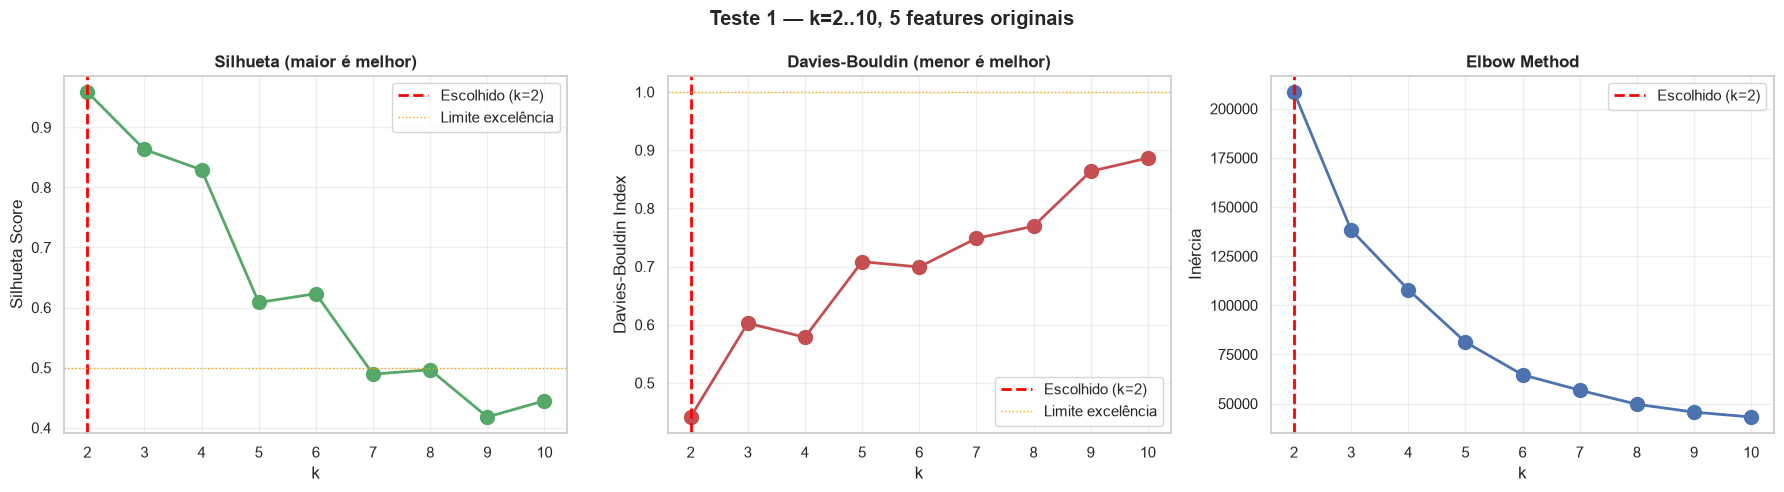

✓ comparativo_k.png salvo em: teste1_k2


In [6]:
# Varredura de k e escolha automática (reproduz o teste original)
cmp_t1, modelos_t1 = sweep_k(X_t1_scaled, range(2, 11))
display(cmp_t1)

k_auto_t1 = int(cmp_t1.loc[cmp_t1['silhueta'].idxmax(), 'k'])
print(f"\nk escolhido automaticamente pela maior silhueta: {k_auto_t1}")
plot_comparativo_k(cmp_t1, k_auto_t1, 'Teste 1 — k=2..10, 5 features originais', dirs=[OUT_T1])

In [7]:
# Treino final do Teste 1 (k=2, conforme escolha automática original)
FINAL_K_T1 = k_auto_t1
kmeans_t1, clusters_t1 = modelos_t1[FINAL_K_T1]
data_t1['cluster'] = clusters_t1

sil_t1 = silhouette_score(X_t1_scaled, clusters_t1)
db_t1 = davies_bouldin_score(X_t1_scaled, clusters_t1)

print(f"Teste 1 — k={FINAL_K_T1}")
print(f"Silhueta: {sil_t1:.4f} ({interpretar_silhueta(sil_t1)})")
print(f"Davies-Bouldin: {db_t1:.4f} ({interpretar_db(db_t1)})")
print(f"\nDistribuição de clusters:")
print(data_t1['cluster'].value_counts().sort_index())

registrar_teste(
    'Teste 1', 'k automático (maior silhueta), 5 features originais, agregação manual',
    FEATURES_T1, FINAL_K_T1, data_t1, sil_t1, db_t1,
)

salvar_csv(
    data_t1[['cod_cliente', 'nome_cliente'] + FEATURES_T1 + ['setor', 'canal', 'cluster']].sort_values('cluster'),
    'segmentacao_clientes.csv', dirs=[OUT_T1], index=False, encoding='utf-8-sig'
)

Teste 1 — k=2
Silhueta: 0.9588 (Excelente)
Davies-Bouldin: 0.4414 (Excelente)

Distribuição de clusters:
cluster
0    7281
1      18
Name: count, dtype: int64
✓ Teste 1 registrado no quadro comparativo.
✓ segmentacao_clientes.csv salvo em: teste1_k2


## Teste 2 e 3 — 5 features do EDA (k=4 e k=5)

A partir daqui, os testes usam o dataset por cliente já preparado no `1.EDA_Kmeans.ipynb`
(cache em `outputs/eda_pricing/kmeans_clientes_features.pkl`), com 5 features:
`volume_total`, `preco_liquido_ponderado`, `margem_pct_ponderada`, `frequencia_mensal`,
`taxa_devolucao`. `volume_total` e `preco_liquido_ponderado` têm caudas muito longas —
sem cortar outliers extremos (percentis 1%-99%), o K-Means isola cada outlier como seu
próprio cluster (tamanho 1), independente do k escolhido. Testes 2 e 3 compartilham o
mesmo pré-processamento; só muda o k final.

In [8]:
# Carregar dataset do EDA e preparar as 5 features
customer_features_full = pd.read_pickle(EDA_CACHE)
print(f"✓ {len(customer_features_full):,} clientes carregados do EDA")

FEATURES_5F = ['volume_total', 'preco_liquido_ponderado', 'margem_pct_ponderada',
               'frequencia_mensal', 'taxa_devolucao']

data_5f = customer_features_full[
    (customer_features_full['volume_total'] > 0) &
    (customer_features_full['receita_liquida_total'] > 0) &
    (customer_features_full['margem_pct_ponderada'].notna())
].copy()

outlier_cols_5f = ['volume_total', 'preco_liquido_ponderado']
n_antes = len(data_5f)
mask = pd.Series(True, index=data_5f.index)
for col in outlier_cols_5f:
    q01, q99 = data_5f[col].quantile([0.01, 0.99])
    mask &= data_5f[col].between(q01, q99)
    print(f"{col}: mantendo faixa [{q01:.2f}, {q99:.2f}]")
data_5f = data_5f[mask].copy()
print(f"\nAntes: {n_antes:,} | Após corte de outliers: {len(data_5f):,} clientes")

X_5f = data_5f[FEATURES_5F].fillna(data_5f[FEATURES_5F].mean())
scaler_5f = RobustScaler()
X_5f_scaled = scaler_5f.fit_transform(X_5f)

✓ 7,507 clientes carregados do EDA
volume_total: mantendo faixa [0.04, 188.19]
preco_liquido_ponderado: mantendo faixa [8623.81, 28101.01]

Antes: 7,507 | Após corte de outliers: 7,236 clientes


,k,inercia,silhueta,davies_bouldin,min_cluster,max_cluster,balance_%
0,2,29120.625784,0.667396,0.702951,483,6753,7.152377
1,3,23321.494940,0.450919,0.960220,204,6030,3.383085
2,4,19215.910750,0.356952,1.040028,204,5005,4.075924
3,5,16872.376515,0.254818,1.096776,198,3680,5.380435


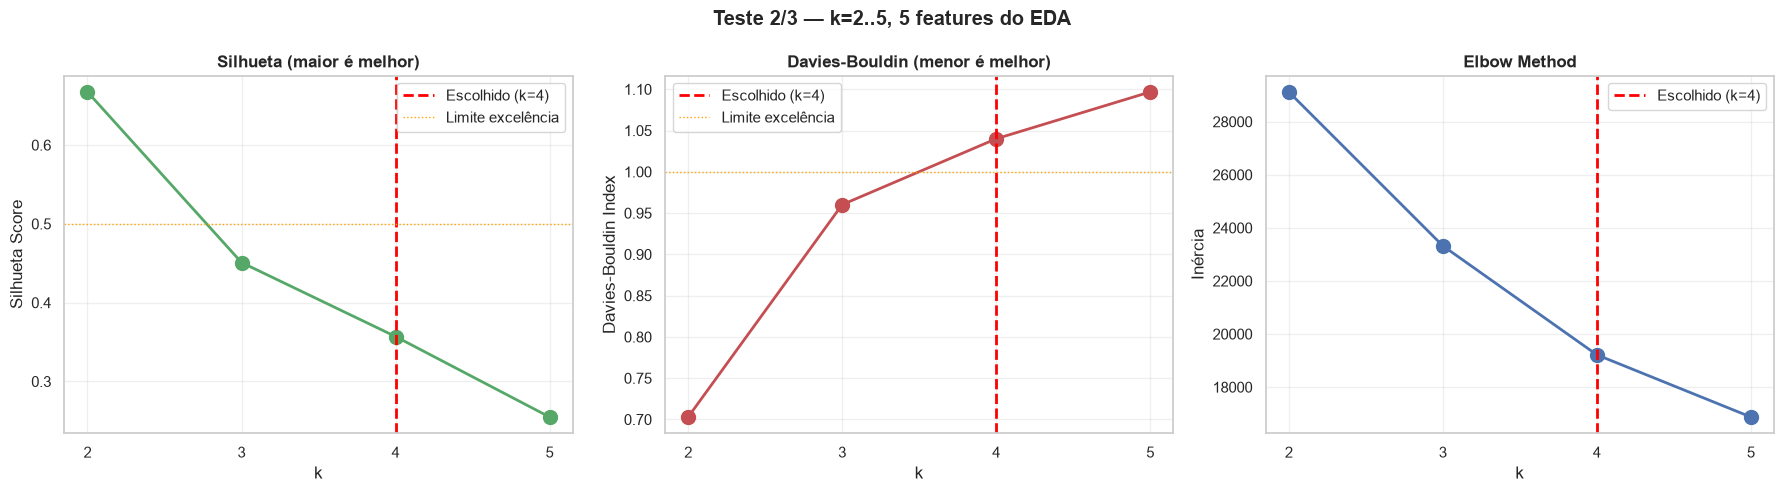

✓ comparativo_k.png salvo em: teste2_k4_5f, teste3_k5_5f


In [9]:
cmp_5f, modelos_5f = sweep_k(X_5f_scaled, range(2, 6))
display(cmp_5f)
plot_comparativo_k(cmp_5f, 4, 'Teste 2/3 — k=2..5, 5 features do EDA', dirs=[OUT_T2, OUT_T3])

In [10]:
# Teste 2: k=4
kmeans_t2, clusters_t2 = modelos_5f[4]
data_5f_t2 = data_5f.copy()
data_5f_t2['cluster'] = clusters_t2
sil_t2 = silhouette_score(X_5f_scaled, clusters_t2)
db_t2 = davies_bouldin_score(X_5f_scaled, clusters_t2)

print(f"Teste 2 — k=4 | Silhueta: {sil_t2:.4f} ({interpretar_silhueta(sil_t2)}) | "
      f"Davies-Bouldin: {db_t2:.4f} ({interpretar_db(db_t2)})")
print(data_5f_t2['cluster'].value_counts().sort_index())

registrar_teste('Teste 2', '5 features do EDA, outliers cortados', FEATURES_5F, 4, data_5f_t2, sil_t2, db_t2)

cols_export = ['Código Cliente', 'nome_cliente'] + FEATURES_5F + ['cluster']
salvar_csv(data_5f_t2[cols_export].sort_values('cluster'), 'segmentacao_clientes.csv',
           dirs=[OUT_T2], index=False, encoding='utf-8-sig')

Teste 2 — k=4 | Silhueta: 0.3570 (Aceitável) | Davies-Bouldin: 1.0400 (Aceitável)
cluster
0    1059
1     968
2     204
3    5005
Name: count, dtype: int64
✓ Teste 2 registrado no quadro comparativo.
✓ segmentacao_clientes.csv salvo em: teste2_k4_5f


In [11]:
# Teste 3: k=5
kmeans_t3, clusters_t3 = modelos_5f[5]
data_5f_t3 = data_5f.copy()
data_5f_t3['cluster'] = clusters_t3
sil_t3 = silhouette_score(X_5f_scaled, clusters_t3)
db_t3 = davies_bouldin_score(X_5f_scaled, clusters_t3)

print(f"Teste 3 — k=5 | Silhueta: {sil_t3:.4f} ({interpretar_silhueta(sil_t3)}) | "
      f"Davies-Bouldin: {db_t3:.4f} ({interpretar_db(db_t3)})")
print(data_5f_t3['cluster'].value_counts().sort_index())

registrar_teste('Teste 3', '5 features do EDA, outliers cortados', FEATURES_5F, 5, data_5f_t3, sil_t3, db_t3)

salvar_csv(data_5f_t3[cols_export].sort_values('cluster'), 'segmentacao_clientes.csv',
           dirs=[OUT_T3], index=False, encoding='utf-8-sig')

Teste 3 — k=5 | Silhueta: 0.2548 (Fraco) | Davies-Bouldin: 1.0968 (Aceitável)
cluster
0    3680
1    1642
2     198
3     906
4     810
Name: count, dtype: int64
✓ Teste 3 registrado no quadro comparativo.
✓ segmentacao_clientes.csv salvo em: teste3_k5_5f


## Teste 4 e 5 — 6 features do EDA + `produtos` (k=4 e k=5)

Adiciona `produtos` (nº de produtos distintos comprados, diversidade de mix) às 5
features anteriores — dimensão citada na conclusão do EDA mas que havia ficado de fora
da seleção original. Também tem cauda longa, então entra no corte de outliers.

In [12]:
FEATURES_6F = FEATURES_5F + ['produtos']

data_6f = customer_features_full[
    (customer_features_full['volume_total'] > 0) &
    (customer_features_full['receita_liquida_total'] > 0) &
    (customer_features_full['margem_pct_ponderada'].notna())
].copy()

outlier_cols_6f = ['volume_total', 'preco_liquido_ponderado', 'produtos']
n_antes = len(data_6f)
mask = pd.Series(True, index=data_6f.index)
for col in outlier_cols_6f:
    q01, q99 = data_6f[col].quantile([0.01, 0.99])
    mask &= data_6f[col].between(q01, q99)
    print(f"{col}: mantendo faixa [{q01:.2f}, {q99:.2f}]")
data_6f = data_6f[mask].copy()
print(f"\nAntes: {n_antes:,} | Após corte de outliers: {len(data_6f):,} clientes")

X_6f = data_6f[FEATURES_6F].fillna(data_6f[FEATURES_6F].mean())
scaler_6f = RobustScaler()
X_6f_scaled = scaler_6f.fit_transform(X_6f)

volume_total: mantendo faixa [0.04, 188.19]
preco_liquido_ponderado: mantendo faixa [8623.81, 28101.01]
produtos: mantendo faixa [1.00, 42.00]

Antes: 7,507 | Após corte de outliers: 7,176 clientes


,k,inercia,silhueta,davies_bouldin,min_cluster,max_cluster,balance_%
0,2,31312.540040,0.628259,0.760696,533,6643,8.023483
1,3,24717.252049,0.421738,1.017314,214,5799,3.690291
2,4,20635.782547,0.336833,1.082104,214,4824,4.436153
3,5,18046.832203,0.301398,1.141275,129,4071,3.168755


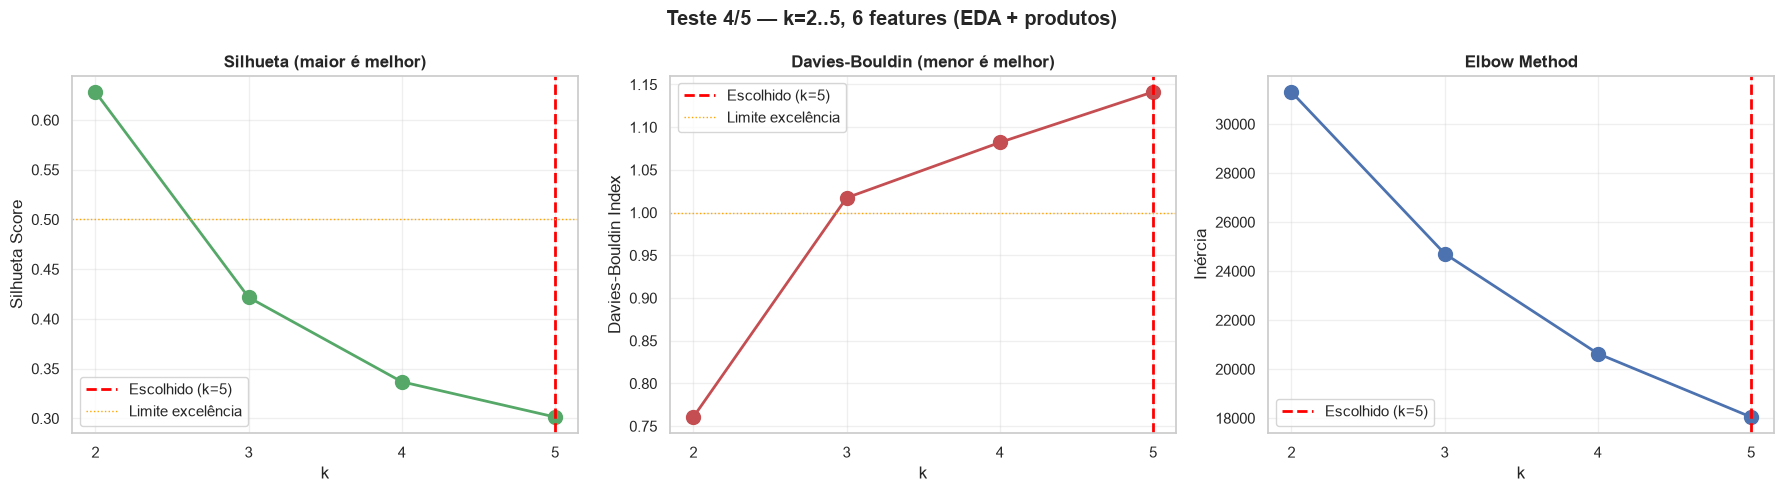

✓ comparativo_k.png salvo em: teste4_k4_6f, teste5_k5_6f


In [13]:
cmp_6f, modelos_6f = sweep_k(X_6f_scaled, range(2, 6))
display(cmp_6f)
plot_comparativo_k(cmp_6f, 5, 'Teste 4/5 — k=2..5, 6 features (EDA + produtos)', dirs=[OUT_T4, OUT_T5])

In [14]:
# Teste 4: k=4
kmeans_t4, clusters_t4 = modelos_6f[4]
data_6f_t4 = data_6f.copy()
data_6f_t4['cluster'] = clusters_t4
sil_t4 = silhouette_score(X_6f_scaled, clusters_t4)
db_t4 = davies_bouldin_score(X_6f_scaled, clusters_t4)

print(f"Teste 4 — k=4 | Silhueta: {sil_t4:.4f} ({interpretar_silhueta(sil_t4)}) | "
      f"Davies-Bouldin: {db_t4:.4f} ({interpretar_db(db_t4)})")
print(data_6f_t4['cluster'].value_counts().sort_index())

registrar_teste('Teste 4', '6 features do EDA (+produtos), outliers cortados', FEATURES_6F, 4, data_6f_t4, sil_t4, db_t4)

cols_export_6f = ['Código Cliente', 'nome_cliente'] + FEATURES_6F + ['cluster']
salvar_csv(data_6f_t4[cols_export_6f].sort_values('cluster'), 'segmentacao_clientes.csv',
           dirs=[OUT_T4], index=False, encoding='utf-8-sig')

Teste 4 — k=4 | Silhueta: 0.3368 (Aceitável) | Davies-Bouldin: 1.0821 (Aceitável)
cluster
0    4824
1    1133
2    1005
3     214
Name: count, dtype: int64
✓ Teste 4 registrado no quadro comparativo.
✓ segmentacao_clientes.csv salvo em: teste4_k4_6f


### Teste 5 — k=5, 6 features — **melhor resultado**

Este é o resultado final adotado. Todos os artefatos a partir daqui são gravados em
`teste5_k5_6f/` **e também** copiados para a raiz de `outputs/` sem prefixo — são os
arquivos oficiais.

In [15]:
# Teste 5: k=5 (MELHOR RESULTADO — treino final)
FINAL_K = 5
kmeans_final, clusters_final = modelos_6f[FINAL_K]
data_final = data_6f.copy()
data_final['cluster'] = clusters_final
scaler_final = scaler_6f
FEATURES = FEATURES_6F
DIRS_FINAL = [OUT_T5, OUTPUT_DIR]

silhouette_final = silhouette_score(X_6f_scaled, clusters_final)
db_final = davies_bouldin_score(X_6f_scaled, clusters_final)

print(f"Teste 5 — k={FINAL_K} | Silhueta: {silhouette_final:.4f} ({interpretar_silhueta(silhouette_final)}) | "
      f"Davies-Bouldin: {db_final:.4f} ({interpretar_db(db_final)})")
print(f"\nDistribuição de clusters:")
pct_final = (data_final['cluster'].value_counts(normalize=True).sort_index() * 100).round(1)
print(data_final['cluster'].value_counts().sort_index())

registrar_teste('Teste 5', '6 features do EDA (+produtos), outliers cortados — MELHOR RESULTADO',
                FEATURES, FINAL_K, data_final, silhouette_final, db_final)

Teste 5 — k=5 | Silhueta: 0.3014 (Aceitável) | Davies-Bouldin: 1.1413 (Aceitável)

Distribuição de clusters:
cluster
0    4071
1     129
2     525
3     883
4    1568
Name: count, dtype: int64
✓ Teste 5 registrado no quadro comparativo.


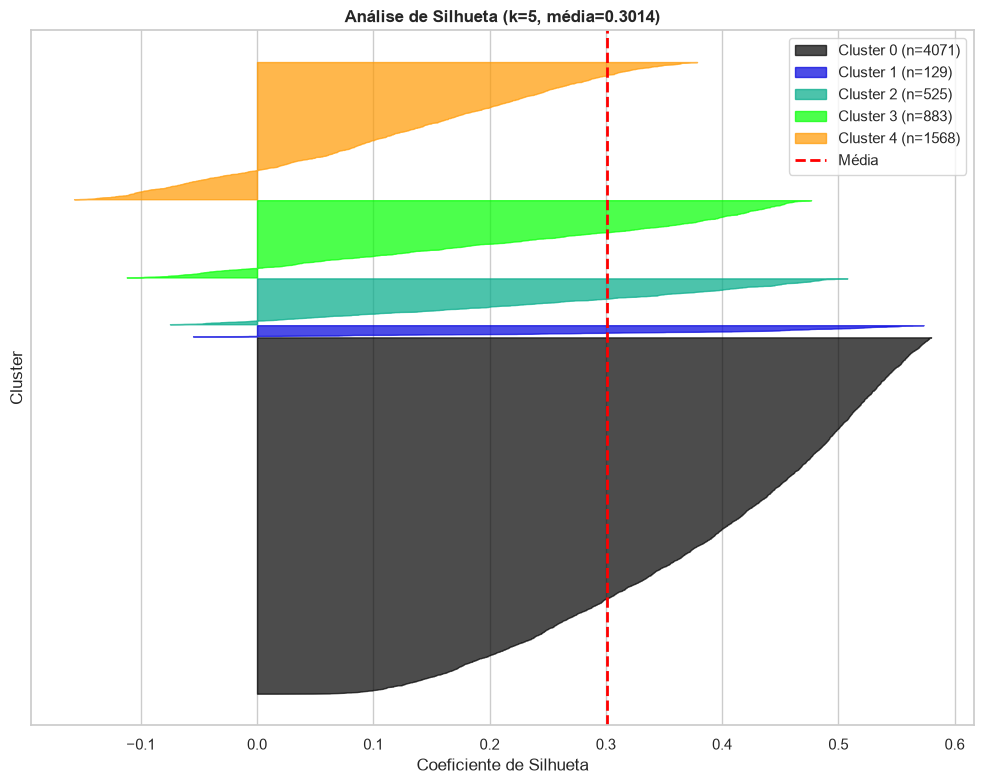

✓ 03_silhouette_by_cluster.png salvo


In [16]:
# Silhueta detalhada por cluster
sample_silhouette_values = silhouette_samples(X_6f_scaled, clusters_final)
fig, ax = plt.subplots(figsize=(10, 8))
y_lower = 10
for i in range(FINAL_K):
    vals = sample_silhouette_values[clusters_final == i]
    vals.sort()
    y_upper = y_lower + len(vals)
    color = plt.cm.nipy_spectral(float(i) / FINAL_K)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=color, edgecolor=color,
                      alpha=0.7, label=f'Cluster {i} (n={len(vals)})')
    y_lower = y_upper + 10
ax.set_xlabel('Coeficiente de Silhueta'); ax.set_ylabel('Cluster')
ax.set_title(f'Análise de Silhueta (k={FINAL_K}, média={silhouette_final:.4f})', fontweight='bold')
ax.axvline(x=silhouette_final, color='red', linestyle='--', linewidth=2, label='Média')
ax.set_yticks([]); ax.legend(loc='best')
plt.tight_layout()
for d in DIRS_FINAL:
    plt.savefig(d / '03_silhouette_by_cluster.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 03_silhouette_by_cluster.png salvo")

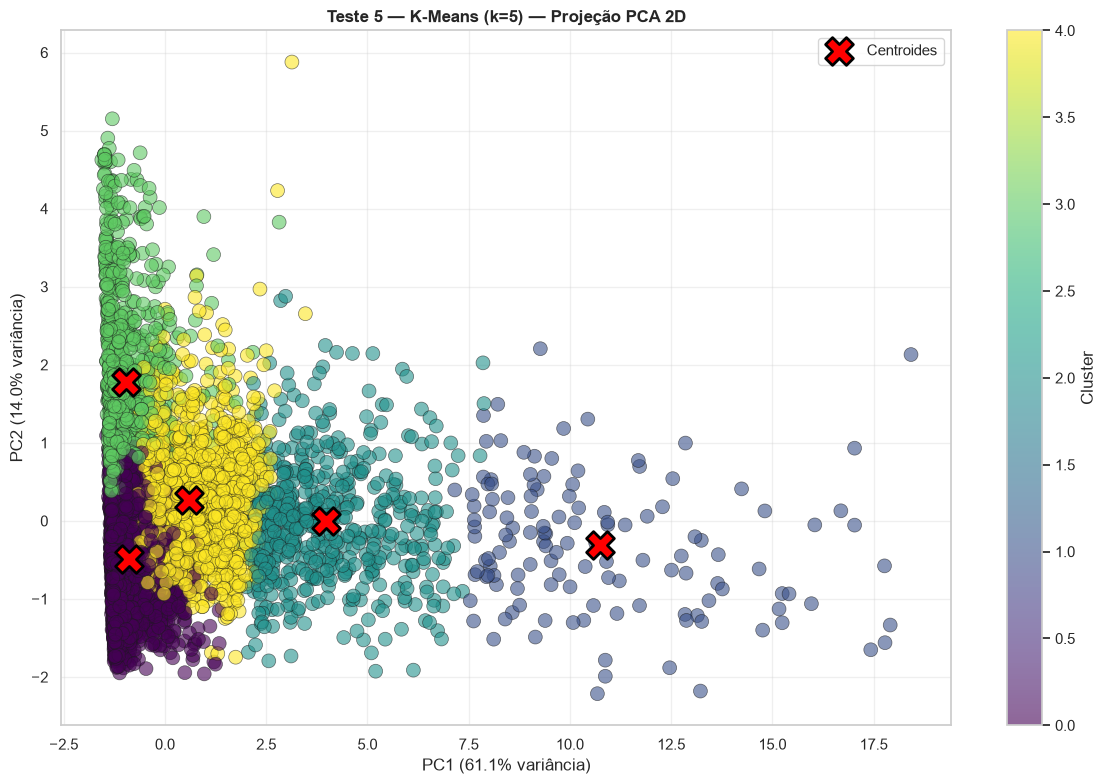

Variância explicada (PC1 + PC2): 75.2%
✓ 04_kmeans_pca_2d.png salvo


In [17]:
# PCA 2D com centroides
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_6f_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=clusters_final, cmap='viridis',
                      s=100, alpha=0.6, edgecolors='k', linewidth=0.5)
centroids_pca = pca_2d.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=400,
           edgecolors='black', linewidths=2, label='Centroides', zorder=5)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variância)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variância)')
ax.set_title(f'Teste 5 — K-Means (k={FINAL_K}) — Projeção PCA 2D', fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.legend(loc='best'); ax.grid(True, alpha=0.3)
plt.tight_layout()
for d in DIRS_FINAL:
    plt.savefig(d / '04_kmeans_pca_2d.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Variância explicada (PC1 + PC2): {pca_2d.explained_variance_ratio_.sum():.1%}")
print("✓ 04_kmeans_pca_2d.png salvo")

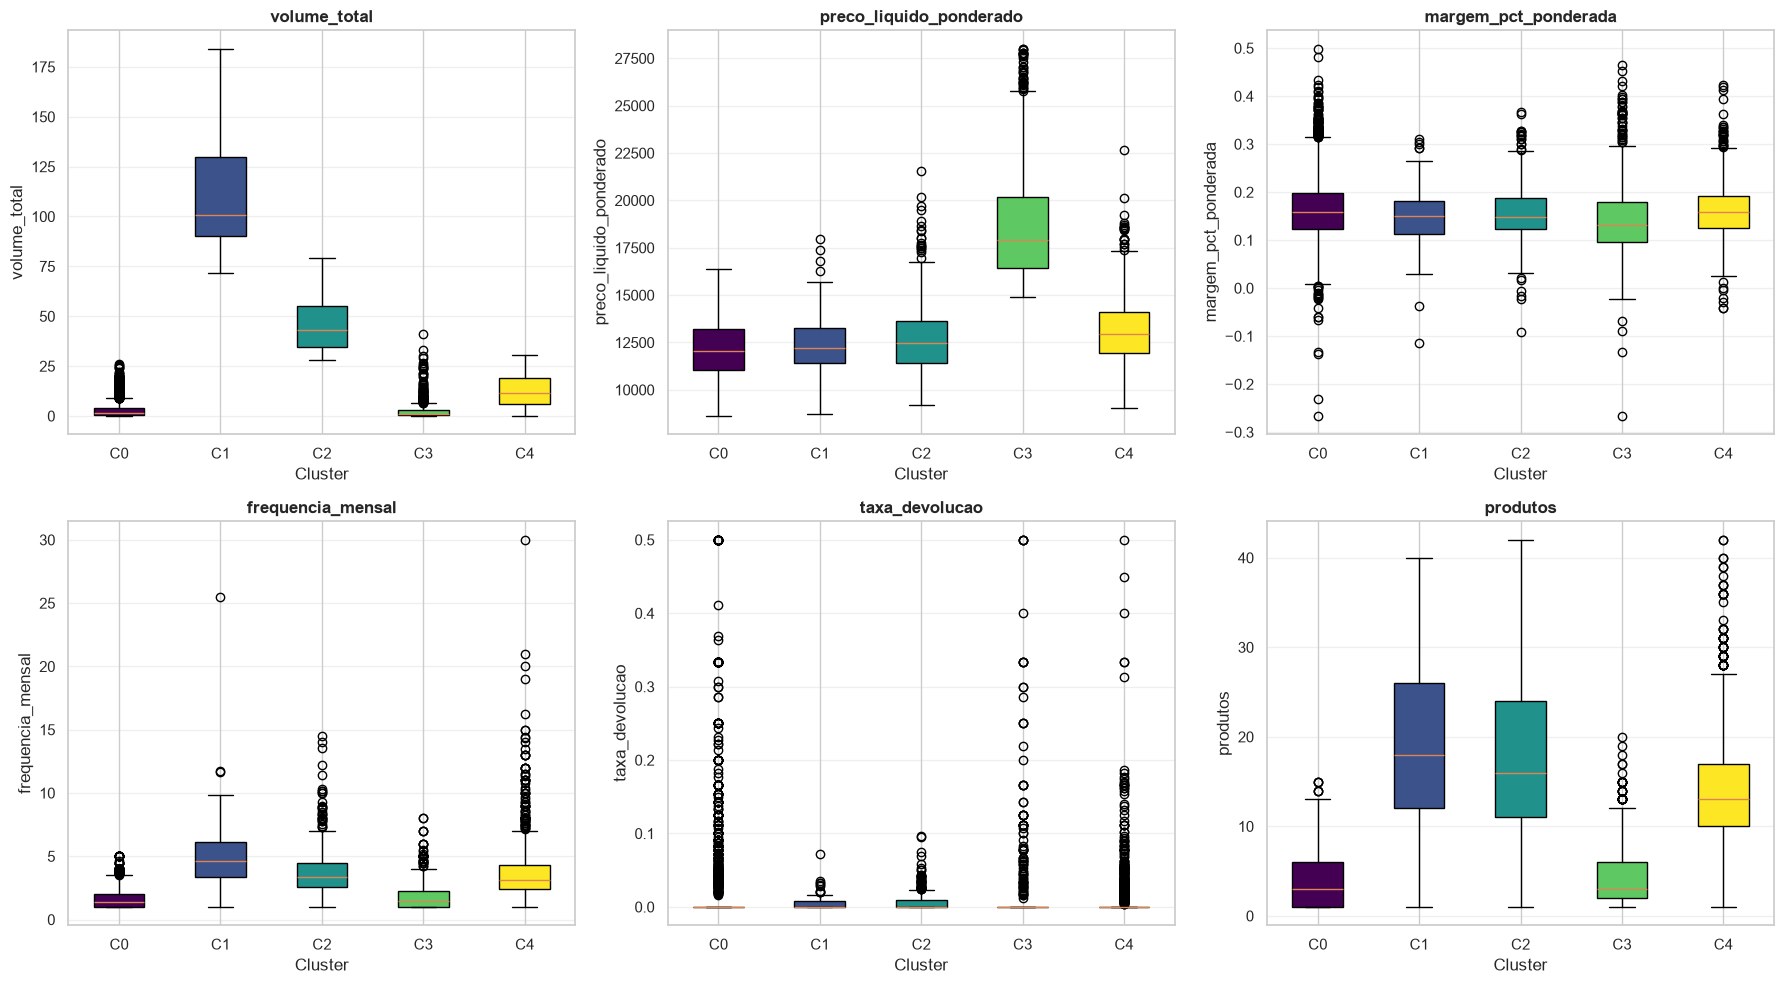

✓ 06_features_boxplot.png salvo


In [18]:
# Boxplots por cluster
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, feature in enumerate(FEATURES):
    ax = axes[idx]
    data_for_box = [data_final[data_final['cluster'] == c][feature].values for c in range(FINAL_K)]
    bp = ax.boxplot(data_for_box, tick_labels=[f'C{c}' for c in range(FINAL_K)], patch_artist=True)
    for patch, color in zip(bp['boxes'], plt.cm.viridis(np.linspace(0, 1, FINAL_K))):
        patch.set_facecolor(color)
    ax.set_xlabel('Cluster'); ax.set_ylabel(feature); ax.set_title(feature, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
for extra in range(len(FEATURES), len(axes)):
    fig.delaxes(axes[extra])
plt.tight_layout()
for d in DIRS_FINAL:
    plt.savefig(d / '06_features_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ 06_features_boxplot.png salvo")

In [19]:
# Características por cluster
cluster_analysis = data_final.groupby('cluster')[FEATURES].agg(['mean', 'std', 'min', 'max'])
print("CARACTERÍSTICAS POR CLUSTER")
display(cluster_analysis)
cluster_means = data_final.groupby('cluster')[FEATURES].mean().round(3)
print("\nMÉDIAS POR CLUSTER")
display(cluster_means)

CARACTERÍSTICAS POR CLUSTER


volume_total                           preco_liquido_ponderado  \
                mean        std    min     max                    mean   
cluster                                                                  
0           2.911164   3.571232   0.04   26.30            12149.301023   
1         111.486589  28.388243  71.66  184.05            12470.888753   
2          45.767581  13.346975  28.27   78.98            12730.827838   
3           2.570861   4.342578   0.04   41.23            18759.518513   
4          12.869273   7.828327   0.22   30.60            13126.594617   

                                                 margem_pct_ponderada  \
                 std           min           max                 mean   
cluster                                                                 
0        1540.402643   8624.200000  16362.250000             0.165379   
1        1681.415244   8718.700762  17983.103550             0.149747   
2        1905.324177   9183.503429  21555.389766             0.156480   
3        2965.404632  14876.190000  28001.625000             0.144217   
4        1657.409731   9018.069158  22648.010784             0.159804   

                                      frequencia_mensal                       \
              std       min       max              mean       std  min   max   
cluster                                                                        
0        0.066539 -0.266243  0.498547          1.640201  0.758283  1.0   5.0   
1        0.061564 -0.114811  0.309679          5.011830  2.781952  1.0  25.5   
2        0.059813 -0.092395  0.366524          3.740066  1.941308  1.0  14.5   
3        0.078039 -0.265926  0.465101          1.886573  1.074699  1.0   8.0   
4        0.053947 -0.041025  0.423646          3.712952  2.144055  1.0  30.0   

        taxa_devolucao                            produtos                    
                  mean       std  min       max       mean       std min max  
cluster                                                                       
0             0.013225  0.058241  0.0  0.500000   3.839352  2.844925   1  15  
1             0.005513  0.009837  0.0  0.072581  19.457364  9.557399   1  40  
2             0.006652  0.012613  0.0  0.096774  17.470476  8.763517   1  42  
3             0.012311  0.053238  0.0  0.500000   4.451869  3.616337   1  20  
4             0.009720  0.033326  0.0  0.500000  14.484056  5.985496   1  42


MÉDIAS POR CLUSTER


,volume_total,preco_liquido_ponderado,margem_pct_ponderada,frequencia_mensal,taxa_devolucao,produtos
cluster,,,,,,
0,2.911,12149.301,0.165,1.640,0.013,3.839
1,111.487,12470.889,0.150,5.012,0.006,19.457
2,45.768,12730.828,0.156,3.740,0.007,17.470
3,2.571,18759.519,0.144,1.887,0.012,4.452
4,12.869,13126.595,0.160,3.713,0.010,14.484


In [20]:
# Salvar modelos finais (Teste 5 + cópia oficial na raiz)
for d in DIRS_FINAL:
    joblib.dump(kmeans_final, d / 'kmeans_model.pkl')
    joblib.dump(scaler_final, d / 'scaler.pkl')
    joblib.dump(pca_2d, d / 'pca_2d.pkl')
print("✓ Modelos salvos: kmeans_model.pkl, scaler.pkl, pca_2d.pkl")

✓ Modelos salvos: kmeans_model.pkl, scaler.pkl, pca_2d.pkl


In [21]:
# Exportar segmentação final
export_cols = ['Código Cliente', 'nome_cliente'] + FEATURES + ['receita_liquida_total', 'cluster']
output_export = data_final[export_cols].sort_values('cluster').copy()
salvar_csv(output_export, 'segmentacao_clientes_kmeans.csv', dirs=DIRS_FINAL, index=False, encoding='utf-8-sig')
display(output_export.head(10))

resumo_clusters = data_final.groupby('cluster')[FEATURES].agg(['count', 'mean', 'std', 'min', 'max'])
salvar_csv(resumo_clusters, 'resumo_clusters.csv', dirs=DIRS_FINAL, encoding='utf-8-sig')

✓ segmentacao_clientes_kmeans.csv salvo em: teste5_k5_6f, 2. Clusterização


,Código Cliente,nome_cliente,volume_total,preco_liquido_ponderado,margem_pct_ponderada,frequencia_mensal,taxa_devolucao,produtos,receita_liquida_total,cluster
18,1469,COMANDO DA MARINHA,1.92,12742.625000,0.228668,2.888889,0.000000,12,24465.84,0
50,3025,CONSIGAZ-DISTRIBUIDORA DE GAS LTDA,1.80,12510.011111,0.156999,1.250000,0.000000,3,22518.02,0
5141,1688265,ACREFORT AGROINDUSTRIAL LTDA,0.60,11961.550000,0.130851,3.500000,0.000000,4,7176.93,0
48,3016,CENTRO OESTE ASFALTOS S/A,1.40,10334.964286,0.209603,1.000000,0.000000,1,14468.95,0
47,3015,CENTRO OESTE ASFALTOS S/A,11.60,10014.875862,0.162324,1.000000,0.000000,1,116172.56,0
5140,1688166,VILASA CONSTRUTORA S/A.,8.79,10247.249147,0.114893,2.750000,0.000000,6,90073.32,0
44,2852,VIACAO REGIONAL S/A,5.06,14690.557312,0.271185,1.700000,0.028571,6,74334.22,0
5139,1687818,G7 INDUSTRIA E COMERCIO DE FERTILIZ,1.56,13052.871795,0.167992,3.000000,0.000000,8,20362.48,0
5138,1687811,PAUMA E BRASIL EMPREENDIMENTOS IMOB,4.41,12550.022676,0.175652,2.250000,0.000000,5,55345.60,0
7423,1898410,CONSTRUTORA CATHIO LTDA,0.40,13319.525000,0.091584,2.500000,0.000000,4,5327.81,0


✓ resumo_clusters.csv salvo em: teste5_k5_6f, 2. Clusterização


In [22]:
# Recomendações de estratégia de pricing por cluster
recommendations = []
for cluster_id in range(FINAL_K):
    cd = data_final[data_final['cluster'] == cluster_id]
    means = cd[FEATURES].mean()
    volume = means['volume_total']
    freq = means['frequencia_mensal']
    if volume > data_final['volume_total'].quantile(0.75):
        strategy = "Volume Pricing: desconto por volume"
    elif freq > data_final['frequencia_mensal'].quantile(0.75):
        strategy = "Frequency Pricing: desconto por frequência"
    else:
        strategy = "Standard Pricing: preço base com pequenos ajustes"
    recommendations.append({
        'cluster': cluster_id, 'n_clientes': len(cd), 'pct_total': f"{len(cd) / len(data_final) * 100:.1f}%",
        'volume_medio': round(means['volume_total'], 2), 'produtos_medio': round(means['produtos'], 2),
        'estrategia': strategy,
    })
rec_df = pd.DataFrame(recommendations)
print("RECOMENDAÇÕES DE ESTRATÉGIA DE PRICING")
display(rec_df)
salvar_csv(rec_df, 'recomendacoes_pricing.csv', dirs=DIRS_FINAL, index=False, encoding='utf-8-sig')

RECOMENDAÇÕES DE ESTRATÉGIA DE PRICING


,cluster,n_clientes,pct_total,volume_medio,produtos_medio,estrategia
0,0,4071,56.7%,2.91,3.84,Standard Pricing: preço base com pequenos ajustes
1,1,129,1.8%,111.49,19.46,Volume Pricing: desconto por volume
2,2,525,7.3%,45.77,17.47,Volume Pricing: desconto por volume
3,3,883,12.3%,2.57,4.45,Standard Pricing: preço base com pequenos ajustes
4,4,1568,21.9%,12.87,14.48,Volume Pricing: desconto por volume


✓ recomendacoes_pricing.csv salvo em: teste5_k5_6f, 2. Clusterização


## Conclusões e Quadro Comparativo

In [23]:
comparativo = pd.DataFrame(resultados_testes)
comparativo.to_csv(OUTPUT_DIR / 'comparativo_testes_kmeans.csv', index=False, encoding='utf-8-sig')

print("QUADRO COMPARATIVO — ORDEM DE EXECUÇÃO")
display(comparativo[['teste', 'k', 'n_features', 'silhueta', 'davies_bouldin',
                      'menor_cluster_%', 'maior_cluster_%', 'n_clientes']])

print("\nQUADRO COMPARATIVO — ORDENADO POR SILHUETA (melhor primeiro)")
display(comparativo.sort_values('silhueta', ascending=False)[
    ['teste', 'k', 'n_features', 'silhueta', 'davies_bouldin', 'menor_cluster_%', 'maior_cluster_%']
])

QUADRO COMPARATIVO — ORDEM DE EXECUÇÃO


,teste,k,n_features,silhueta,davies_bouldin,menor_cluster_%,maior_cluster_%,n_clientes
0,Teste 1,2,5,0.9588,0.4414,0.2,99.8,7299
1,Teste 2,4,5,0.3570,1.0400,2.8,69.2,7236
2,Teste 3,5,5,0.2548,1.0968,2.7,50.9,7236
3,Teste 4,4,6,0.3368,1.0821,3.0,67.2,7176
4,Teste 5,5,6,0.3014,1.1413,1.8,56.7,7176



QUADRO COMPARATIVO — ORDENADO POR SILHUETA (melhor primeiro)


,teste,k,n_features,silhueta,davies_bouldin,menor_cluster_%,maior_cluster_%
0,Teste 1,2,5,0.9588,0.4414,0.2,99.8
1,Teste 2,4,5,0.3570,1.0400,2.8,69.2
3,Teste 4,4,6,0.3368,1.0821,3.0,67.2
4,Teste 5,5,6,0.3014,1.1413,1.8,56.7
2,Teste 3,5,5,0.2548,1.0968,2.7,50.9


In [24]:
print(f"""
{'='*90}
CONCLUSÕES
{'='*90}

O QUE APRENDEMOS AO LONGO DOS 5 TESTES:

1. TESTE 1 (k=2, features originais) — a escolha automática de k pela maior silhueta
   ({resultados_testes[0]['silhueta']:.4f}) pareceu "excelente", mas a distribuição real foi
   {resultados_testes[0]['distribuicao']}.
   Isso é um artefato: poucos clientes com valores extremos ficam tão distantes do resto
   que qualquer corte os isola como cluster próprio — silhueta alta não significa
   segmentação útil para negócio.

2. TESTES 2 e 3 (5 features do EDA, com corte de outliers 1%-99%) — corrigem o problema
   acima. k=4 (Teste 2) e k=5 (Teste 3) produzem clusters de tamanho comercialmente
   utilizável, com silhueta mais "realista" (mais baixa, mas honesta).

3. TESTES 4 e 5 (6 features, +produtos/diversidade) — adicionar a diversidade de
   produtos comprados como feature melhora a qualidade da segmentação em k=5
   (silhueta {resultados_testes[4]['silhueta']:.4f} vs {resultados_testes[2]['silhueta']:.4f} sem essa feature) e revela um
   segmento de clientes "grande volume + diversificado" que as 5 features originais
   não capturavam.

RECOMENDAÇÃO FINAL: {resultados_testes[4]['teste']} — k={resultados_testes[4]['k']}, {resultados_testes[4]['n_features']} features.
  Silhueta: {resultados_testes[4]['silhueta']:.4f} ({interpretar_silhueta(resultados_testes[4]['silhueta'])})
  Davies-Bouldin: {resultados_testes[4]['davies_bouldin']:.4f} ({interpretar_db(resultados_testes[4]['davies_bouldin'])})
  Distribuição: {resultados_testes[4]['distribuicao']}

ARQUIVOS FINAIS (Teste 5, na raiz de outputs/, sem prefixo):
  - segmentacao_clientes_kmeans.csv
  - resumo_clusters.csv
  - recomendacoes_pricing.csv
  - comparativo_testes_kmeans.csv (este quadro)
  - kmeans_model.pkl, scaler.pkl, pca_2d.pkl
  - 03_silhouette_by_cluster.png, 04_kmeans_pca_2d.png, 06_features_boxplot.png

ARQUIVOS POR TESTE (uma pasta cada, para auditoria/comparação):
  - outputs/teste1_k2/
  - outputs/teste2_k4_5f/
  - outputs/teste3_k5_5f/
  - outputs/teste4_k4_6f/
  - outputs/teste5_k5_6f/  (idêntico aos arquivos finais na raiz)

PRÓXIMOS PASSOS:
  1. Validar os {FINAL_K} clusters do Teste 5 com o time de negócio
  2. Nomear clusters comercialmente (ex: conforme volume/diversidade de produtos)
  3. Testar elasticidade de preço por cluster
  4. Implementar em pipeline de pricing
  5. Monitorar estabilidade mensal/trimestral
{'='*90}
""")


CONCLUSÕES

O QUE APRENDEMOS AO LONGO DOS 5 TESTES:

1. TESTE 1 (k=2, features originais) — a escolha automática de k pela maior silhueta
   (0.9588) pareceu "excelente", mas a distribuição real foi
   0: 7281 (99.8%), 1: 18 (0.2%).
   Isso é um artefato: poucos clientes com valores extremos ficam tão distantes do resto
   que qualquer corte os isola como cluster próprio — silhueta alta não significa
   segmentação útil para negócio.

2. TESTES 2 e 3 (5 features do EDA, com corte de outliers 1%-99%) — corrigem o problema
   acima. k=4 (Teste 2) e k=5 (Teste 3) produzem clusters de tamanho comercialmente
   utilizável, com silhueta mais "realista" (mais baixa, mas honesta).

3. TESTES 4 e 5 (6 features, +produtos/diversidade) — adicionar a diversidade de
   produtos comprados como feature melhora a qualidade da segmentação em k=5
   (silhueta 0.3014 vs 0.2548 sem essa feature) e revela um
   segmento de clientes "grande volume + diversificado" que as 5 features originais
   não captura

## Teste extra — impacto de remover `preco_liquido_ponderado`

Não é um dos 5 testes oficiais acima — é um diagnóstico pontual para responder a uma pergunta específica: **a segmentação do Teste 5 depende de usar preço como feature, ou os mesmos clusters apareceriam sem ele?** Usa exatamente os mesmos 7.176 clientes do Teste 5 (`data_final`), a mesma metodologia (RobustScaler, KMeans k=5, `random_state=42`, `n_init=20`) e as mesmas 5 features restantes — só remove `preco_liquido_ponderado` do vetor de entrada.


In [25]:
FEATURES_NOPRICE = [f for f in FEATURES if f != 'preco_liquido_ponderado']
print(f"Features (sem preço): {FEATURES_NOPRICE}")

X_noprice = data_final[FEATURES_NOPRICE].fillna(data_final[FEATURES_NOPRICE].mean())
scaler_noprice = RobustScaler()
X_noprice_scaled = scaler_noprice.fit_transform(X_noprice)

kmeans_noprice = KMeans(n_clusters=5, random_state=42, n_init=20, max_iter=500, tol=1e-4)
clusters_noprice = kmeans_noprice.fit_predict(X_noprice_scaled)

sil_noprice = silhouette_score(X_noprice_scaled, clusters_noprice)
db_noprice = davies_bouldin_score(X_noprice_scaled, clusters_noprice)

print(f"Sem preço — k=5, 5 features | Silhueta: {sil_noprice:.4f} ({interpretar_silhueta(sil_noprice)}) | "
      f"Davies-Bouldin: {db_noprice:.4f} ({interpretar_db(db_noprice)})")
print(f"Com preço  — k=5, 6 features | Silhueta: {silhouette_final:.4f} ({interpretar_silhueta(silhouette_final)}) | "
      f"Davies-Bouldin: {db_final:.4f} ({interpretar_db(db_final)})")

data_noprice = data_final.copy()
data_noprice['cluster'] = clusters_noprice
dist_noprice = data_noprice['cluster'].value_counts().sort_index()
pct_noprice = (dist_noprice / dist_noprice.sum() * 100).round(1)
print("\nDistribuição de clusters (sem preço):")
display(pd.DataFrame({'n_clientes': dist_noprice, 'pct': pct_noprice}))


Features (sem preço): ['volume_total', 'margem_pct_ponderada', 'frequencia_mensal', 'taxa_devolucao', 'produtos']


Sem preço — k=5, 5 features | Silhueta: 0.2981 (Fraco) | Davies-Bouldin: 1.0099 (Aceitável)
Com preço  — k=5, 6 features | Silhueta: 0.3014 (Aceitável) | Davies-Bouldin: 1.1413 (Aceitável)

Distribuição de clusters (sem preço):


,n_clientes,pct
cluster,,
0,3421,47.7
1,510,7.1
2,128,1.8
3,1467,20.4
4,1650,23.0


### Os clusters mudam?

Tabela de contingência: quantos clientes de cada cluster do Teste 5 (linhas) caíram em cada cluster do modelo sem preço (colunas). Se as duas segmentações fossem idênticas, cada linha teria um só valor grande e o resto zero. O Adjusted Rand Index (ARI) resume a concordância geral: 1,0 = idêntico, 0,0 = concordância ao nível do acaso.


In [26]:
from sklearn.metrics import adjusted_rand_score

contingencia = pd.crosstab(data_final['cluster'], clusters_noprice,
                            rownames=['cluster_com_preco'], colnames=['cluster_sem_preco'])
display(contingencia)

ari = adjusted_rand_score(data_final['cluster'], clusters_noprice)
print(f"\nAdjusted Rand Index (com preço vs sem preço): {ari:.3f}")


cluster_sem_preco,0,1,2,3,4
cluster_com_preco,,,,,
0,2673,0,0,17,1381
1,0,1,128,0,0
2,0,507,0,17,1
3,632,2,0,55,194
4,116,0,0,1378,74



Adjusted Rand Index (com preço vs sem preço): 0.429


### Perfil dos clusters sem preço (com preço exibido só para leitura, não usado no treino)


In [27]:
perfil_noprice = data_noprice.groupby('cluster')[FEATURES].mean().round(3)
perfil_noprice.insert(0, 'n_clientes', dist_noprice)
perfil_noprice.insert(1, 'pct', pct_noprice)
print("PERFIL DOS CLUSTERS — MODELO SEM PREÇO (mas mostrando preço médio de cada um, para comparação)")
display(perfil_noprice)

print("\nPara comparação, perfil dos clusters do Teste 5 (com preço):")
display(cluster_means)


PERFIL DOS CLUSTERS — MODELO SEM PREÇO (mas mostrando preço médio de cada um, para comparação)


,n_clientes,pct,volume_total,preco_liquido_ponderado,margem_pct_ponderada,frequencia_mensal,taxa_devolucao,produtos
cluster,,,,,,,,
0,3421,47.7,2.901,13286.450,0.125,1.743,0.013,4.229
1,510,7.1,46.373,12810.751,0.156,3.741,0.007,17.435
2,128,1.8,111.753,12451.507,0.149,5.000,0.006,19.328
3,1467,20.4,13.687,13241.792,0.158,3.807,0.010,14.853
4,1650,23.0,2.880,13268.762,0.240,1.625,0.014,3.838



Para comparação, perfil dos clusters do Teste 5 (com preço):


,volume_total,preco_liquido_ponderado,margem_pct_ponderada,frequencia_mensal,taxa_devolucao,produtos
cluster,,,,,,
0,2.911,12149.301,0.165,1.640,0.013,3.839
1,111.487,12470.889,0.150,5.012,0.006,19.457
2,45.768,12730.828,0.156,3.740,0.007,17.470
3,2.571,18759.519,0.144,1.887,0.012,4.452
4,12.869,13126.595,0.160,3.713,0.010,14.484


### Salvar artefatos do teste extra


✓ segmentacao_sem_preco.csv salvo em: teste_extra_sem_preco
✓ contingencia_com_vs_sem_preco.csv salvo em: teste_extra_sem_preco
✓ perfil_clusters_sem_preco.csv salvo em: teste_extra_sem_preco


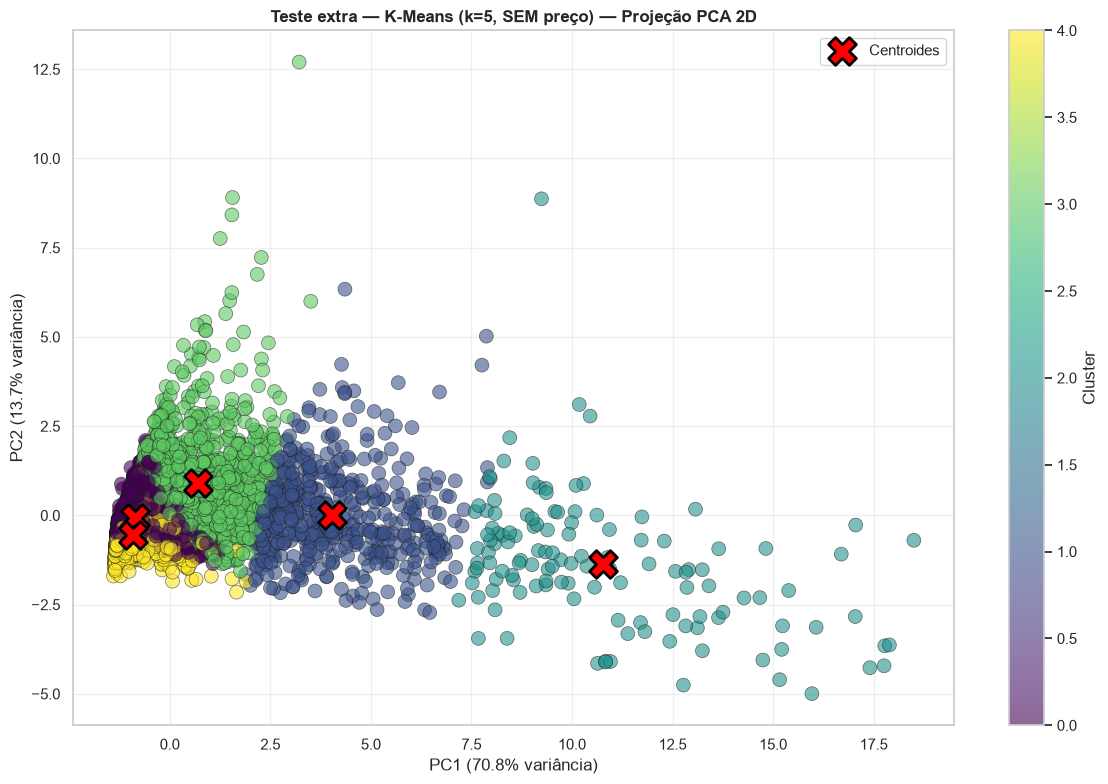

Variância explicada (PC1 + PC2): 84.5%
✓ Artefatos do teste extra salvos em outputs/2. Clusterização/1.Kmeans_testes/teste_extra_sem_preco/


In [28]:
OUT_EXTRA = OUTPUT_DIR / '1.Kmeans_testes' / 'teste_extra_sem_preco'
OUT_EXTRA.mkdir(parents=True, exist_ok=True)

cols_export_noprice = ['Código Cliente', 'nome_cliente'] + FEATURES_NOPRICE + ['preco_liquido_ponderado', 'cluster']
salvar_csv(data_noprice[cols_export_noprice].sort_values('cluster'), 'segmentacao_sem_preco.csv',
           dirs=[OUT_EXTRA], index=False, encoding='utf-8-sig')
salvar_csv(contingencia, 'contingencia_com_vs_sem_preco.csv', dirs=[OUT_EXTRA], encoding='utf-8-sig')
salvar_csv(perfil_noprice, 'perfil_clusters_sem_preco.csv', dirs=[OUT_EXTRA], encoding='utf-8-sig')

# PCA 2D do modelo sem preço, para comparação visual com 04_kmeans_pca_2d.png (Teste 5)
pca_2d_noprice = PCA(n_components=2)
X_pca_2d_noprice = pca_2d_noprice.fit_transform(X_noprice_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(X_pca_2d_noprice[:, 0], X_pca_2d_noprice[:, 1], c=clusters_noprice, cmap='viridis',
                      s=100, alpha=0.6, edgecolors='k', linewidth=0.5)
centroids_pca_noprice = pca_2d_noprice.transform(kmeans_noprice.cluster_centers_)
ax.scatter(centroids_pca_noprice[:, 0], centroids_pca_noprice[:, 1], c='red', marker='X', s=400,
           edgecolors='black', linewidths=2, label='Centroides', zorder=5)
ax.set_xlabel(f'PC1 ({pca_2d_noprice.explained_variance_ratio_[0]:.1%} variância)')
ax.set_ylabel(f'PC2 ({pca_2d_noprice.explained_variance_ratio_[1]:.1%} variância)')
ax.set_title('Teste extra — K-Means (k=5, SEM preço) — Projeção PCA 2D', fontweight='bold')
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.legend(loc='best'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_EXTRA / '04b_kmeans_pca_2d_sem_preco.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Variância explicada (PC1 + PC2): {pca_2d_noprice.explained_variance_ratio_.sum():.1%}")
print("\u2713 Artefatos do teste extra salvos em outputs/2. Clusterização/1.Kmeans_testes/teste_extra_sem_preco/")
